In [1]:
import numpy as np
from fmri_timescales.timescale_utils import TD
import fig05


n_timepoints, n_repeats = 4800, 1000

phi = 0.8
tau = -1 / np.log(phi)

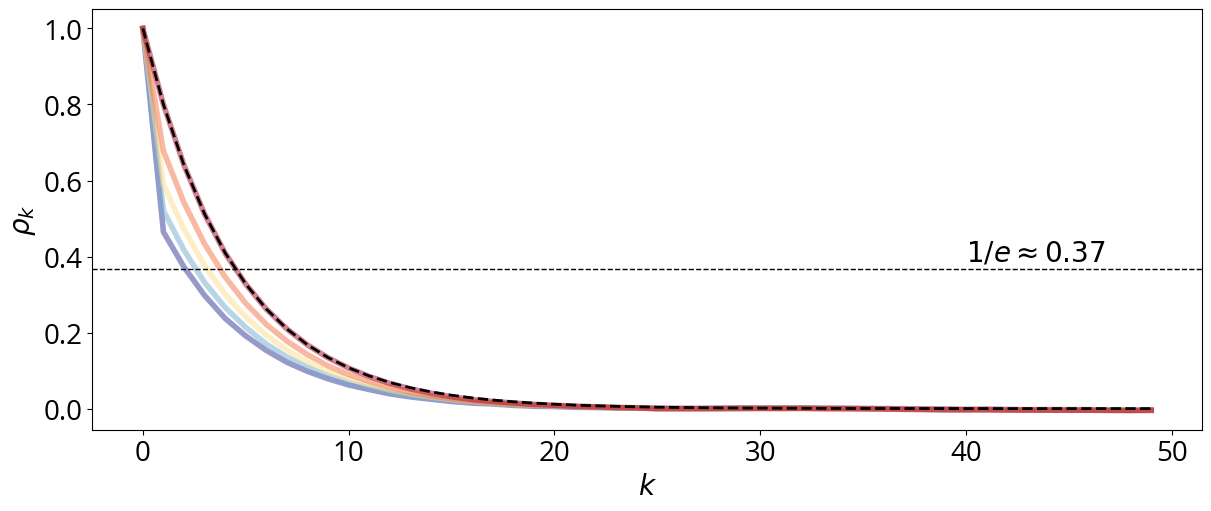

In [2]:
import matplotlib.pyplot as plt
from fmri_timescales import sim, acf_utils

# set notebook defaults
plt.rcParams.update({"font.size": 20, "font.sans-serif": ["Open Sans"]})
np.set_printoptions(precision=3)

n_lags = 50
acf = acf_utils.ACF(n_lags=n_lags)
colors = ["#313695", "#72ABD0", "#FEDE8E", "#F57245", "#A70226"]

# fig05-a
fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")

rng = np.random.default_rng(seed=0)

stds = np.sqrt([2, 1.5, 1, 0.5, 0])
X = sim.sim_ar(phi, n_timepoints=1000_000, n_repeats=1, random_seed=2)
for idx, std in enumerate(stds):
    X_mn = X + rng.normal(loc=0, scale=std, size=(1000_000, 1))
    X_acf = acf.fit_transform(X_mn, 1000_000)
    ax.plot(X_acf, c=colors[idx], lw=4, ls="-", alpha=0.5)

ax.plot(phi ** np.arange(50), lw=2, ls="--", c="k")

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$\rho_k$")
ax.axhline(y=1 / np.e, color="k", linestyle="--", linewidth=1)
ax.annotate(r"$1/e \approx 0.37$", xy=(40, 1 / np.e), xytext=(40, 1 / np.e + 0.02))
fig.savefig("../figures/fig05-acf.pdf", bbox_inches="tight")

31
26
31
31
1


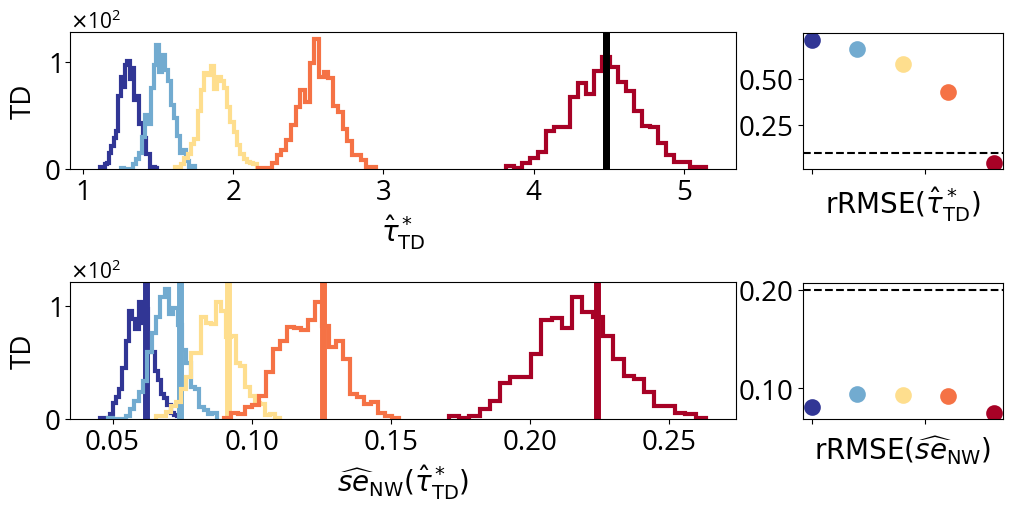

In [3]:
td = TD(var_estimator="newey-west", n_jobs=-1, var_n_lags=20)
results = fig05.run_simulation(phi, n_timepoints, td)
fig = fig05.plot_simulation(results, tau)
fig.savefig("../figures/fig05-ar1.png", dpi=300, bbox_inches="tight", transparent=True)

156
51
26
16
11


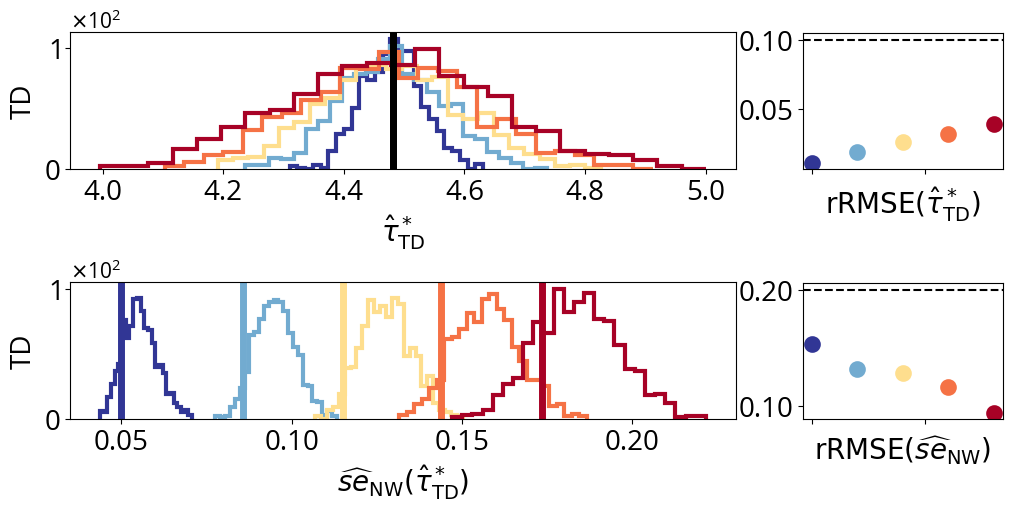

In [4]:
td = TD(var_estimator="newey-west", n_jobs=-1)
phis = np.array([[1.52, -0.9], [1.39, -0.7375], [1.26, -0.575], [1.13, -0.4125], [1, -0.25]])
results = fig05.run_simulation(phis, n_timepoints, td)
fig = fig05.plot_simulation(results, tau)
fig.savefig("../figures/fig06-ar2.png", dpi=300, bbox_inches="tight", transparent=True)